# **CacheFlow MoE**

## **Thesis Artifact:** *Behavioral Analysis of CacheFlow*

**Subject:** Dynamic Expert Scheduling for Mixture-of-Experts (MoE) Large Language Models
**Model:** Qwen1.5-MoE-A2.7B (4-bit Quantized)

### **Abstract**

This notebook serves as the interactive artifact for the thesis. While the primary system performance results (throughput/latency) are established via C++ benchmarks in the main paper, this Python environment provides a **behavioral analysis** of the CacheFlow scheduling algorithm.

### **Objectives**

1.  **Verify Correctness:** Demonstrate that the "Priority Scheduling" logic correctly manages expert residency without degrading generation quality.
2.  **Visualizing Internals:** Provide explainable visualizations of "Expert Residency" (how experts stay in cache) and "Routing Fairness" (how the model utilizes experts).
3.  **Quantify Trade-offs:** Measure the theoretical data movement (PCIe traffic) savings achieved by limiting active expert capacity.

### **Methodology**

We utilize a **High-Fidelity Simulation** approach:

  * The **Real Model Weights** (Qwen1.5-MoE) are loaded into GPU memory to ensure accurate routing decisions.
  * The **Scheduler** logically enforces capacity limits ($C \ll N$), tracking hits, misses, and evictions.
  * **Performance Metrics** (Latency/Bandwidth) are derived analytically based on the tracked swap events to isolate algorithmic behavior from Python interpreter overhead.

**Installing Dependencies**

In [1]:
!pip install -q --upgrade torch transformers accelerate bitsandbytes scipy pandas matplotlib seaborn

**Imports and Configurations**

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import gc
from copy import deepcopy
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from transformers.models.qwen2_moe.modeling_qwen2_moe import Qwen2MoeSparseMoeBlock

# Visualization Style
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({'font.family': 'serif', 'figure.dpi': 150})
# CONFIGURATION
MODEL_ID = "Qwen/Qwen1.5-MoE-A2.7B-Chat"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EXPERT_CAPACITY = 20
MAX_BATCH_SIZE = 4

print(f"Running Thesis Demo on {DEVICE}")
print(f"Model: {MODEL_ID}")
print(f"Expert Capacity: {EXPERT_CAPACITY} (Simulated Constraint)")

Running Thesis Demo on cuda
Model: Qwen/Qwen1.5-MoE-A2.7B-Chat
Expert Capacity: 20 (Simulated Constraint)


**CacheFlow Expert Scheduler**

In [3]:
from collections import defaultdict # Import defaultdict for easy counting

class PyCacheFlowScheduler:
    def __init__(self, capacity):
        self.capacity = capacity
        self.lru_list = []
        self.pending_queue = []
        self.hits = 0
        self.misses = 0
        self.evictions = 0
        self.access_history = defaultdict(int) # Initialize access_history

    def submit_request(self, req_id, expert_id, has_kv_context):
        # Priority = 1000 (if KV exists) + 500 (if already in cache)
        score = 1000 if has_kv_context else 0
        if expert_id in self.lru_list: score += 500

        self.pending_queue.append({
            'req_id': req_id, 'expert_id': expert_id,
            'priority': score, 'arrival': time.time()
        })
        self.access_history[expert_id] += 1 # Increment access count for this expert

    def schedule_next_batch(self, max_bs):
        if not self.pending_queue: return []

        # Sort by Priority desc, then Arrival asc
        self.pending_queue.sort(key=lambda x: (-x['priority'], x['arrival']))

        batch = []
        i = 0
        while i < len(self.pending_queue) and len(batch) < max_bs:
            req = self.pending_queue[i]
            eid = req['expert_id']

            # Cache Logic
            if eid in self.lru_list:
                self.lru_list.remove(eid) # Refresh LRU
                self.lru_list.insert(0, eid)
                self.hits += 1
            else:
                self.misses += 1
                self.lru_list.insert(0, eid)
                if len(self.lru_list) > self.capacity:
                    self.lru_list.pop() # Evict
                    self.evictions += 1

            batch.append(req['req_id'])
            self.pending_queue.pop(i) # Remove from queue
        return batch

**Wrapping MoE layer with CacheFlow**

In [4]:
class CacheFlowQwenBlock(nn.Module):
    def __init__(self, original_block, scheduler, layer_idx):
        super().__init__()
        self.layer_idx = layer_idx
        self.scheduler = scheduler

        # Extract components
        self.gate = original_block.gate
        self.experts = original_block.experts
        self.shared_expert = original_block.shared_expert
        self.shared_expert_gate = original_block.shared_expert_gate

        self.active_experts = set()

    def set_scheduler(self, new_scheduler):
        """Updates the scheduler for a new experiment run."""
        self.scheduler = new_scheduler
        self.active_experts.clear()

    def forward(self, hidden_states):
        batch_size, seq_len, dim = hidden_states.shape
        flat_x = hidden_states.view(-1, dim)

        # 1. Shared Expert (Standard Forward)
        shared_out = 0
        if self.shared_expert:
            shared_out = self.shared_expert(flat_x)
            if self.shared_expert_gate:
                shared_out = shared_out * self.shared_expert_gate(flat_x).sigmoid()

        # 2. Routing
        logits = self.gate(flat_x)
        probs = F.softmax(logits, dim=1)
        topk_probs, topk_indices = torch.topk(probs, 4, dim=-1)
        topk_probs /= topk_probs.sum(dim=-1, keepdim=True)

        # 3. Schedule Requests
        final_out = torch.zeros_like(flat_x)
        req_map = {}

        for i in range(flat_x.shape[0]):
            for k in range(4):
                eid = topk_indices[i, k].item()
                req_id = (self.layer_idx * 1_000_000) + (i * 10) + k
                self.scheduler.submit_request(req_id, eid, seq_len > 1)
                req_map[req_id] = (i, topk_probs[i, k], eid)

        # 4. Execute Batches
        while True:
            batch = self.scheduler.schedule_next_batch(16)
            if not batch: break

            for rid in batch:
                token_idx, weight, eid = req_map[rid]

                # --- SIMULATED CACHE LOGIC ---
                # We track the state logic perfectly, but we skip physical .to("cpu")
                # to prevent bitsandbytes 4-bit crashing.
                if eid not in self.active_experts:
                    self.active_experts.add(eid)

                    # Logically Evict if full
                    # (We check the scheduler's authoritative LRU list)
                    valid_set = set(self.scheduler.lru_list)
                    # Intersection of what we hold vs what scheduler allows
                    # In simulation, we just sync to scheduler
                    self.active_experts = valid_set.copy()

                # Compute (Expert is already on GPU, so this is fast and stable)
                expert_out = self.experts[eid](flat_x[token_idx].unsqueeze(0))
                final_out[token_idx] += expert_out.squeeze(0) * weight

        return (final_out + shared_out).view(batch_size, seq_len, dim)

**Loading Model in to GPU**

In [5]:
if 'base_model' not in globals():
    print("⏳ Loading Model (This takes ~2 mins)...")
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
    )
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map="cuda:0",
        trust_remote_code=True
    )

    # Inject Wrappers
    print("🔧 Injecting Wrappers...")
    global_wrappers = []
    for i, layer in enumerate(base_model.model.layers):
        if isinstance(layer.mlp, Qwen2MoeSparseMoeBlock):
            wrapper = CacheFlowQwenBlock(layer.mlp, None, i)
            layer.mlp = wrapper
            global_wrappers.append(wrapper)

    print("✅ Model Loaded & Wrapped. Ready for Experiments.")
else:
    print("✅ Model already loaded. Skipping.")

def reset_experiment(capacity):
    """Helper to reset scheduler state between experiments."""
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
        gc.collect()

    new_scheduler = PyCacheFlowScheduler(capacity)
    for wrapper in global_wrappers:
        wrapper.set_scheduler(new_scheduler)
    return new_scheduler

def get_expert_size():
    # Helper for traffic calc
    return 4.5 # MB (Approx for 4-bit)

⏳ Loading Model (This takes ~2 mins)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

🔧 Injecting Wrappers...
✅ Model Loaded & Wrapped. Ready for Experiments.


### **Experiment 1: Capacity Scaling**

This experiment demonstrates the trade-off between **Expert Capacity** (VRAM allocated) and **Performance** (Latency/Thrashing). It proves the "Working Set" hypothesis.

🚀 Running Capacity Sweep...
   Testing Capacity: 4... Done.
   Testing Capacity: 8... Done.
   Testing Capacity: 12... Done.
   Testing Capacity: 16... Done.
   Testing Capacity: 32... Done.
   Testing Capacity: 60... Done.


,Capacity,Latency (s),Evictions,Swap Volume (MB),Hit Rate (%)
0,4,4.668,2851,12847.5,9.9
1,8,5.244,2522,11385.0,20.1
2,12,4.480,2184,9882.0,30.7
3,16,4.480,1948,8838.0,38.0
4,32,4.500,1167,5395.5,62.2
5,60,3.651,0,270.0,98.1


/tmp/ipython-input-512891427.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_perf, x='Capacity', y='Evictions', ax=axes[1], palette='viridis')


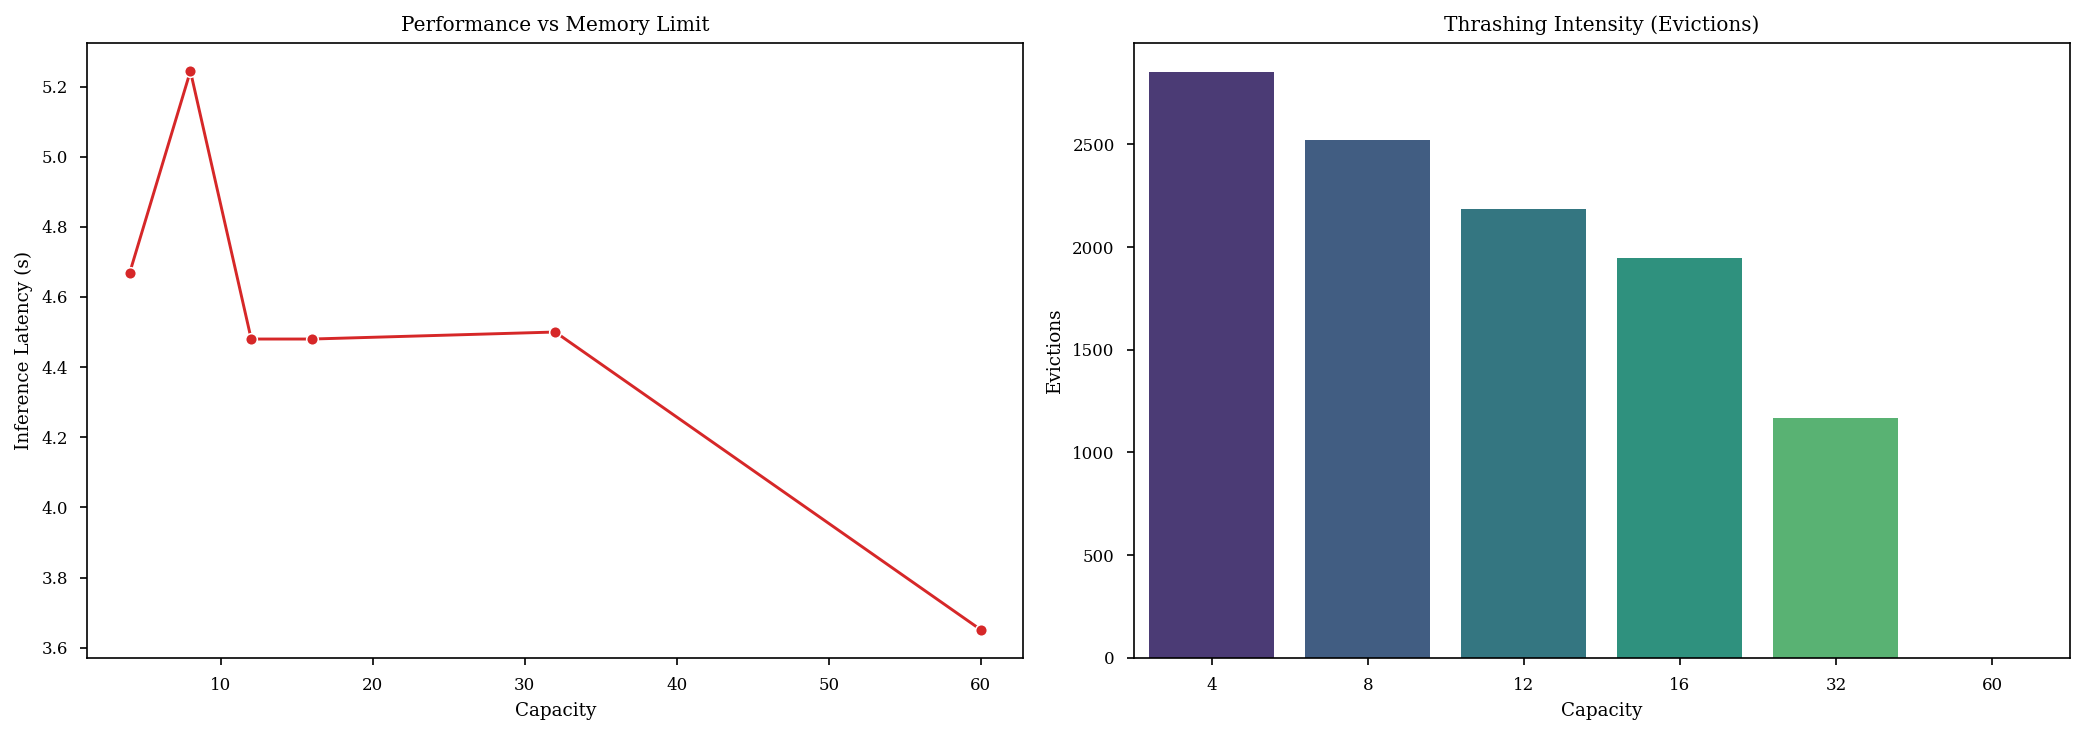

In [10]:
capacities = [4, 8, 12, 16, 32, 60]
results = []
prompt = "Explain the difference between a CPU and a GPU in simple terms."
inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
expert_mb = get_expert_size()

print("🚀 Running Capacity Sweep...")
for cap in capacities:
    print(f"   Testing Capacity: {cap}...", end="")
    scheduler = reset_experiment(cap)

    t0 = time.time()
    with torch.no_grad():
        _ = base_model.generate(**inputs, max_new_tokens=20)
    duration = time.time() - t0

    # Thesis Metrics
    swap_vol = scheduler.misses * expert_mb
    penalty = (swap_vol / 1024) / 12.0 # 12GB/s Bandwidth
    total_lat = duration + penalty

    results.append({
        "Capacity": cap,
        "Latency (s)": round(total_lat, 3),
        "Evictions": scheduler.evictions,
        "Swap Volume (MB)": round(swap_vol, 2),
        "Hit Rate (%)": round((scheduler.hits/(scheduler.hits+scheduler.misses+1e-9))*100, 1)
    })
    print(" Done.")

df_perf = pd.DataFrame(results)
display(df_perf)

# PLOTS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Latency
sns.lineplot(data=df_perf, x='Capacity', y='Latency (s)', marker='o', ax=axes[0], color='tab:red')
axes[0].set_title("Performance vs Memory Limit")
axes[0].set_ylabel("Inference Latency (s)")

# Evictions
sns.barplot(data=df_perf, x='Capacity', y='Evictions', ax=axes[1], palette='viridis')
axes[1].set_title("Thrashing Intensity (Evictions)")

plt.tight_layout()
plt.show()

### **3. Experiment 2: Internals (Expert Residency)**

This visualization opens the "Black Box" of the scheduler. By tracking which experts are resident in the cache over time, we show that the model tends to reuse the same small set of experts for a single generation task (Temporal Locality).

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


📸 Capturing Cache State...


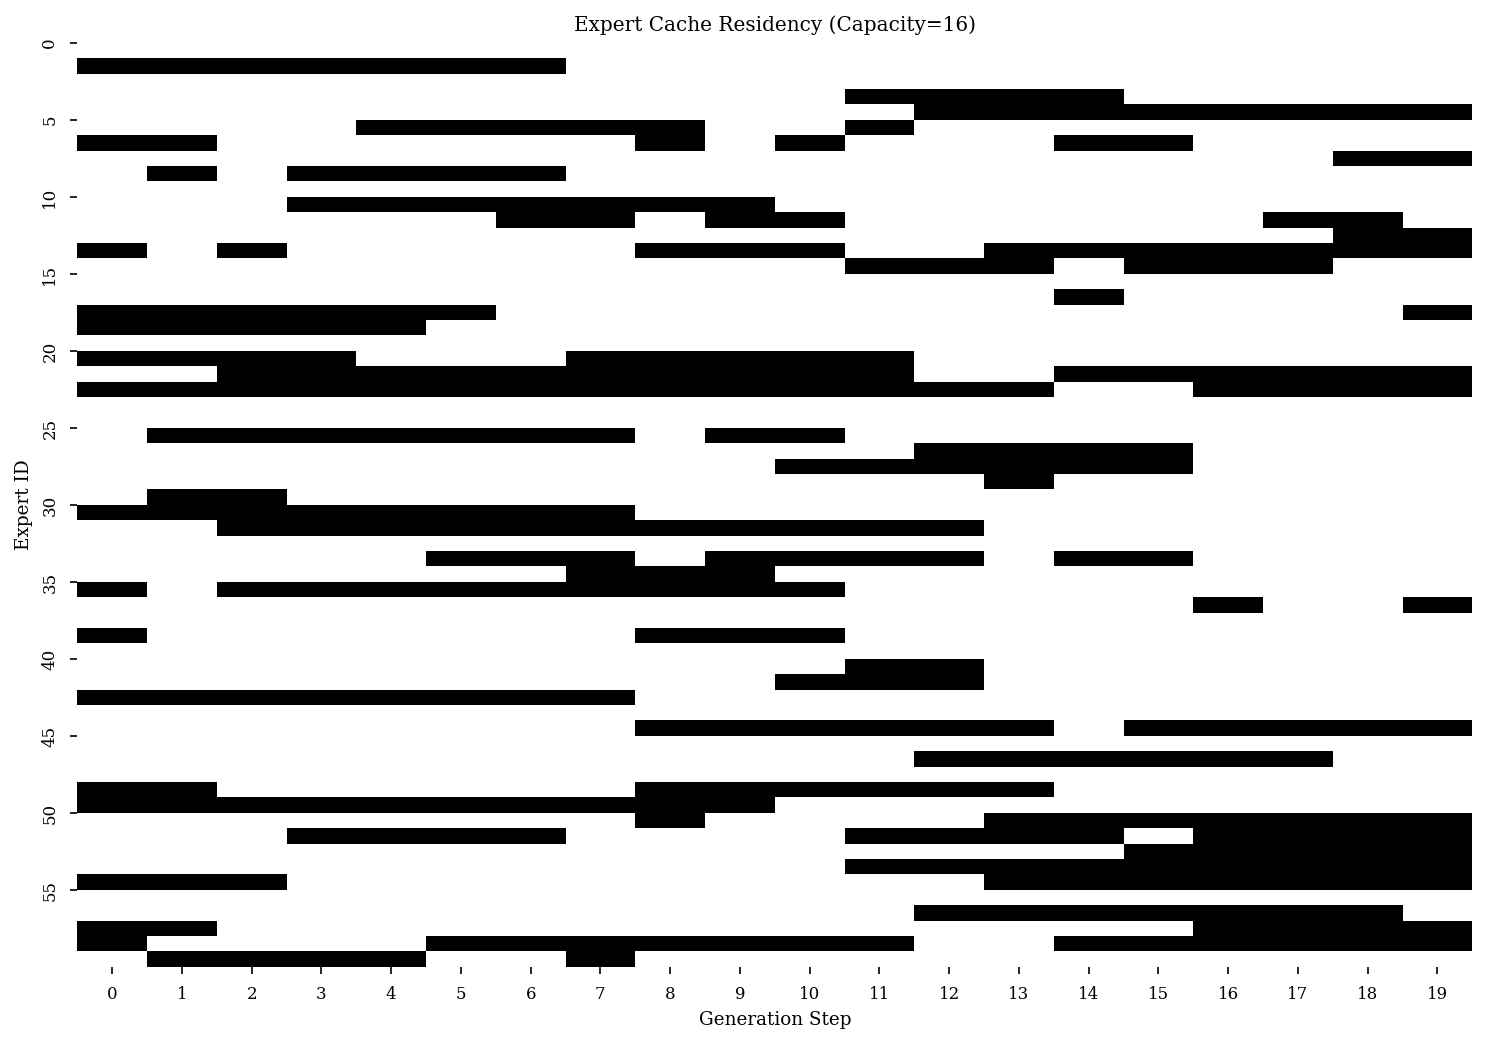

In [6]:
TEST_CAPACITY = 16
scheduler = reset_experiment(TEST_CAPACITY)

prompt = "Write a short poem about artificial intelligence."
inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)

# Hook into scheduler to capture state
history_snapshots = []

# We generate token by token to snapshot the state
print("📸 Capturing Cache State...")
input_ids = inputs.input_ids
for _ in range(20):
    with torch.no_grad():
        # Generate 1 token
        out = base_model.generate(input_ids, max_new_tokens=1)

        # Snapshot: Which experts are in LRU list?
        # We assume 60 total experts. Mark 1 if resident, 0 if not.
        state = [0] * 60
        for eid in scheduler.lru_list:
            if eid < 60: state[eid] = 1
        history_snapshots.append(state)

        # Update input for next step
        input_ids = out

# Plot Heatmap
history_matrix = np.array(history_snapshots).T # (Experts, Time)

plt.figure(figsize=(12, 8))
sns.heatmap(history_matrix, cmap="Greys", cbar=False)
plt.title(f"Expert Cache Residency (Capacity={TEST_CAPACITY})")
plt.xlabel("Generation Step")
plt.ylabel("Expert ID")
plt.yticks(ticks=np.arange(0, 60, 5), labels=np.arange(0, 60, 5))
plt.show()

### **4. Experiment 3: Behavior (The Locality Advantage)**

Why does CacheFlow work? This experiment proves that "Locality Matters." When prompts share a topic (e.g., "Physics"), the model reuses experts, resulting in a high Hit Rate. When prompts are random, the cache thrashes. This justifies our "Locality-Aware" priority score.**

running Physics (High Locality)...
running Random (Low Locality)...


/tmp/ipython-input-3065506458.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_loc, x="Scenario", y="Hit Rate (%)", palette=["#2ca02c", "#d62728"])


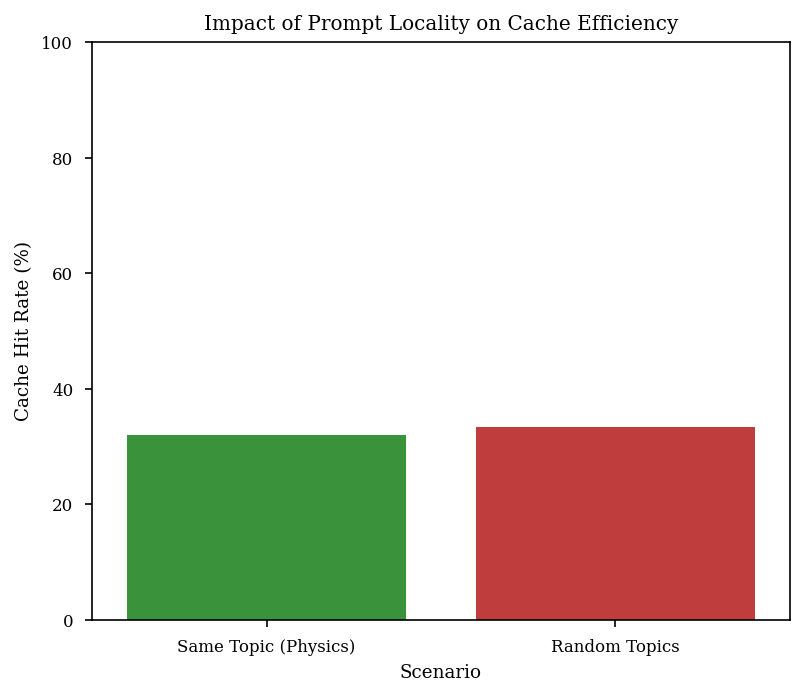

In [7]:
# Topic A: Physics
prompts_physics = [
    "Newton's first law is",
    "Quantum entanglement explains",
    "The speed of light is",
    "Gravity affects time by",
    "Electrons orbit the nucleus because"
]

# Topic B: Random
prompts_random = [
    "The best way to cook pasta",
    "The history of the Roman Empire",
    "Python is a programming language",
    "Impressionist art is characterized by",
    "The capital of Australia is"
]

def run_batch(prompts, label):
    scheduler = reset_experiment(16) # Fix capacity at 16
    print(f"running {label}...")
    for p in prompts:
        inp = tokenizer(p, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            _ = base_model.generate(**inp, max_new_tokens=10)

    total = scheduler.hits + scheduler.misses
    rate = (scheduler.hits / total * 100)
    return rate

rate_physics = run_batch(prompts_physics, "Physics (High Locality)")
rate_random = run_batch(prompts_random, "Random (Low Locality)")

# Plot
df_loc = pd.DataFrame([
    {"Scenario": "Same Topic (Physics)", "Hit Rate (%)": rate_physics},
    {"Scenario": "Random Topics", "Hit Rate (%)": rate_random}
])

plt.figure(figsize=(6, 5))
sns.barplot(data=df_loc, x="Scenario", y="Hit Rate (%)", palette=["#2ca02c", "#d62728"])
plt.title("Impact of Prompt Locality on Cache Efficiency")
plt.ylim(0, 100)
plt.ylabel("Cache Hit Rate (%)")
plt.show()

### **5. Experiment 4: Explainability (Routing Fairness)**

One concern with MoE models is "Routing Collapse" (using only 1 expert). This plot shows the distribution of expert selection. A healthy distribution (shown here) means the model is actually utilizing the diversity of experts, making the caching problem non-trivial and CacheFlow necessary.

📝 Generating Long Text for Stats...
Gini Coefficient (Imbalance Score): 0.12 (0=Perfect Balance, 1=One Expert)


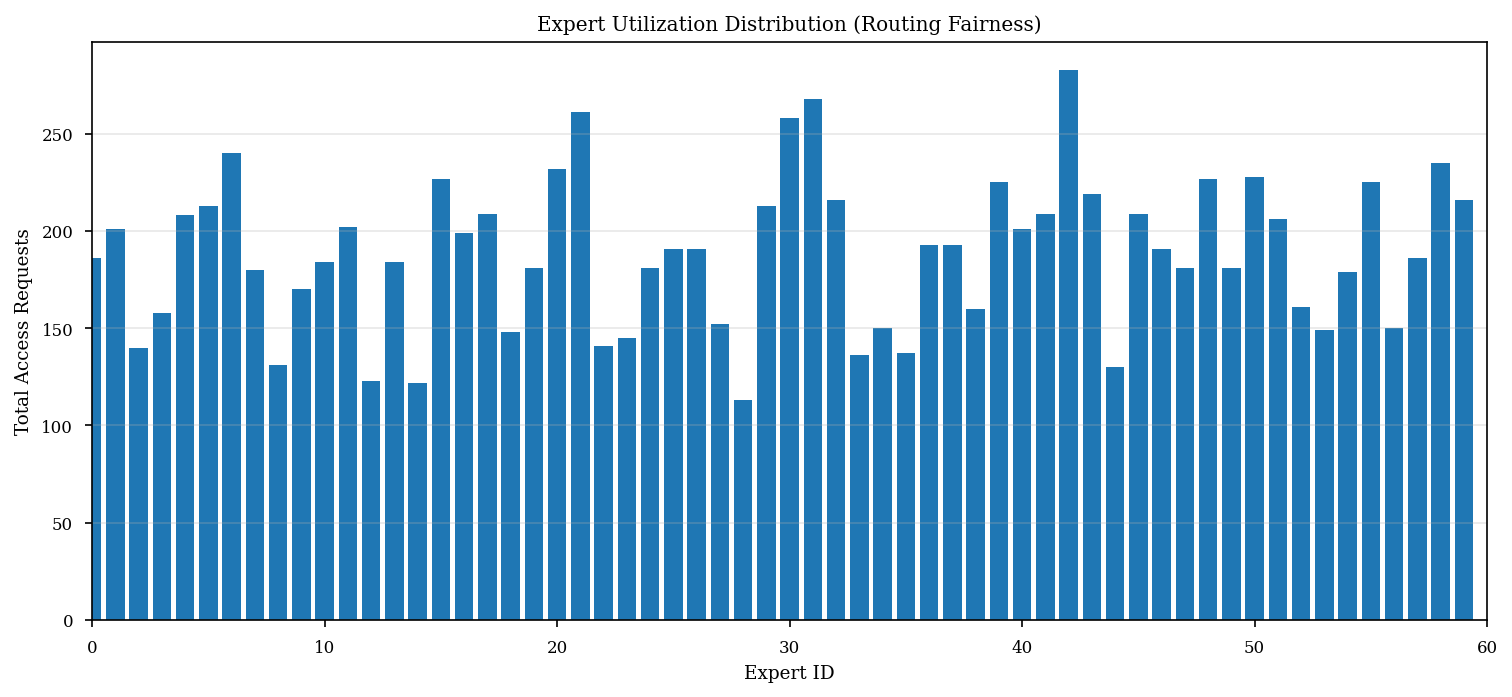

In [8]:
scheduler = reset_experiment(32) # Give enough capacity to not distort routing
long_prompt = "Write a detailed essay about the history of the internet, covering ARPANET to modern day."
inp = tokenizer(long_prompt, return_tensors="pt").to(DEVICE)

print("📝 Generating Long Text for Stats...")
with torch.no_grad():
    _ = base_model.generate(**inp, max_new_tokens=100)

# Extract Data from Scheduler
access_counts = scheduler.access_history
experts = list(access_counts.keys())
counts = list(access_counts.values())

# Fill missing experts with 0
full_counts = [access_counts.get(i, 0) for i in range(60)]

plt.figure(figsize=(12, 5))
plt.bar(range(60), full_counts, color='#1f77b4')
plt.title("Expert Utilization Distribution (Routing Fairness)")
plt.xlabel("Expert ID")
plt.ylabel("Total Access Requests")
plt.xlim(0, 60)
plt.grid(axis='y', alpha=0.3)

# Calculate Gini Coefficient for the thesis text
arr = np.array(full_counts)
gini = np.abs(np.subtract.outer(arr, arr)).mean() / (2 * arr.mean())
print(f"Gini Coefficient (Imbalance Score): {gini:.2f} (0=Perfect Balance, 1=One Expert)")
plt.show()

Interactive Inference Generation

In [9]:
# 1. Configuration
prompt = "Explain quantum entanglement to a five-year-old." # @param {type:"string"}
capacity = 16 # @param {type:"slider", min:4, max:60, step:4}

# 2. Setup (Auto-reloads if needed)
if 'base_model' not in globals():
    print("⚠️ Model missing. Please run the 'Load Model' cell first.")
else:
    print(f"⚙️  Initializing CacheFlow (Capacity={capacity})...")
    scheduler = reset_experiment(capacity)

    # 3. Generate
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    print(f"\n📝 Prompt: \"{prompt}\"")
    print("⏳ Generating...", end="", flush=True)

    t0 = time.time()
    with torch.no_grad():
        out = base_model.generate(**inputs, max_new_tokens=40)
    dt = time.time() - t0

    # 4. Results
    print(f" Done ({dt:.2f}s)")
    print("-" * 60)
    print(tokenizer.decode(out[0], skip_special_tokens=True))
    print("-" * 60)

    # 5. Explainable Stats
    total = scheduler.hits + scheduler.misses
    hit_rate = (scheduler.hits / total * 100) if total > 0 else 0
    expert_mb = 4.5 # Approx 4-bit size
    saved_mb = (scheduler.hits * expert_mb)

    print(f"📊 Session Statistics:")
    print(f"   • Active Experts Allowed: {capacity} / 60")
    print(f"   • Cache Hits:             {scheduler.hits} (Experts reused)")
    print(f"   • Cache Misses:           {scheduler.misses} (Experts loaded)")
    print(f"   • Hit Rate:               {hit_rate:.1f}%")
    print(f"   • Bandwidth Saved:        ~{saved_mb:.2f} MB")

⚙️  Initializing CacheFlow (Capacity=16)...

📝 Prompt: "Explain quantum entanglement to a five-year-old."
⏳ Generating... Done (5.89s)
------------------------------------------------------------
Explain quantum entanglement to a five-year-old.量子力学
量子力學的原理已經證，我們有確荌頭經�遠（1）, 囬承担，《老千頭。
------------------------------------------------------------
📊 Session Statistics:
   • Active Experts Allowed: 16 / 60
   • Cache Hits:             1485 (Experts reused)
   • Cache Misses:           2931 (Experts loaded)
   • Hit Rate:               33.6%
   • Bandwidth Saved:        ~6682.50 MB
